In [75]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling, unfocus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

# Making a Forward Model

## Configure a DM

In [64]:
# First we need a forward model of the system
# NOTE: Influence functions should peak at 1

# Basic inputs to a prysm DM
# - influence function
# - number of actuators in X and Y axes
# - separation of the actuators in the array containing the lattice, in units of samples

nact = 11
act_pitch = 6
samples_per_act = 42
sampling_pitch = act_pitch / samples_per_act

x, y = make_xy_grid(512, dx=sampling_pitch)
r, th = cart_to_polar(x, y)
influence_func = gaussian_influence_function(r, act_pitch)#np.sinc(x/act_pitch) * np.sinc(y/act_pitch)
influence_func /= np.max(influence_func)
Nout = x.shape[0]
dm = DM(influence_func, Nout, nact, samples_per_act, rot=(0,0,0), shift=(samples_per_act, samples_per_act))

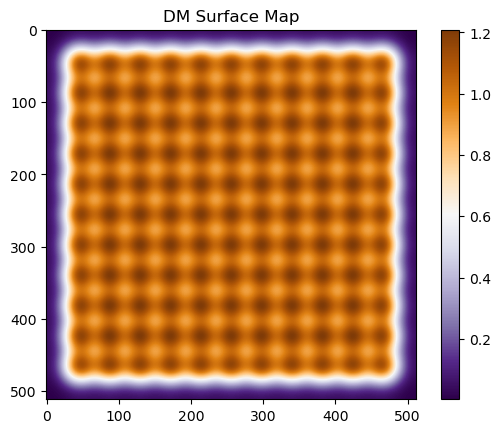

In [66]:
dm.actuators[:] = 1
sfe = dm.render(wfe=False)
plt.title("DM Surface Map")
plt.imshow(sfe, cmap="PuOr_r")
plt.colorbar()

## Configure Wavefront Error

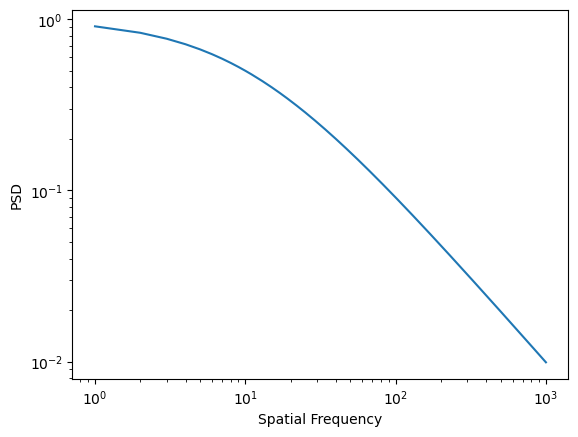

In [67]:
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()

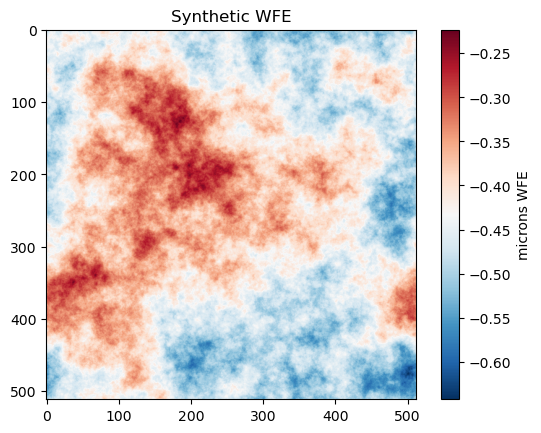

In [68]:
# Just picked ABC values until it looked about right
Npup = Nout
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.show()

## Configure Diffraction Model

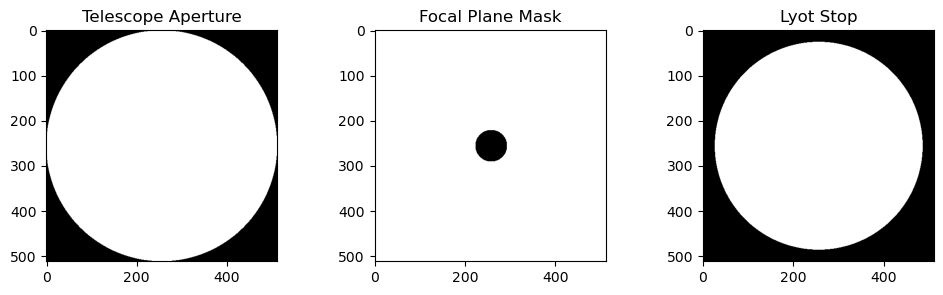

In [74]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
LS = circle(0.9, r)

# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z) # with error

# Sample field
focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
dark_hole[rho < 7] = 1
dark_hole[rho < 4] = 0
dark_hole[u < 3] = 0

FPM = np.ones_like(u)
FPM[ rho < 3.5] = 0

focal_intensity = np.abs(focal)**2

plt.figure(figsize=[12,3])
plt.subplot(131)
plt.imshow(A, cmap='gray')
plt.title('Telescope Aperture')
plt.subplot(132)
plt.imshow(FPM, cmap='gray')
plt.title('Focal Plane Mask')
plt.subplot(133)
plt.imshow(LS, cmap='gray')
plt.title('Lyot Stop')
plt.show()

In [78]:
def snap_image(pupil_wfe=np.zeros_like(A), include_fpm=True):
    """take intensity image given a pupil wfe in microns

    Parameters
    ----------
    pupil_wfe : ndarray, optional
        wavefront error in microns, by default np.ones_like(A)
    """

    # create nominal wavefront
    wfe = np.exp(1j * 2 * np.pi / WVL * pupil_wfe)
    wvfnt_to_prop = wfe * wvfnt

    # propagate to focus
    focal = focus_fixed_sampling(wvfnt_to_prop,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    if include_fpm:
        focal *= FPM

    lyot = unfocus_fixed_sampling(focal,
                                input_dx=dx_img, # um
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=Dpup / wvfnt.shape[0], # mm
                                output_samples=wvfnt.shape[0])
    
    lyot *= LS

    coro = focus_fixed_sampling(lyot,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    return np.abs(coro)**2


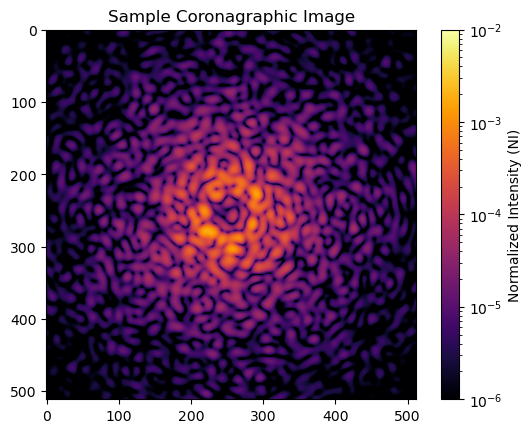

In [83]:
ref_contrast = snap_image(include_fpm=False).max()

plt.figure()
plt.title("Sample Coronagraphic Image")
plt.imshow(snap_image() / ref_contrast, cmap='inferno', norm=LogNorm(vmin=1e-6, vmax=1e-2))
plt.colorbar(label="Normalized Intensity (NI)")
plt.show()

# Apply Waffle Pattern at maximum DM frequency

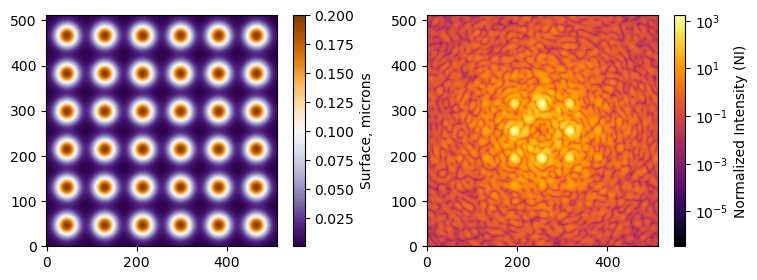

In [110]:
waffle = np.ones_like(dm.actuators) * 1e-1
for i in range(dm.actuators.shape[0]):
    for j in range(dm.actuators.shape[1]):

        if i%2 != 0 or j%2 != 0:
            waffle[i,j] = 0

dm.actuators[:] = waffle

plt.figure(figsize=[9,3])
plt.subplot(121)
plt.imshow(dm.render(), cmap="PuOr_r", origin="lower")
plt.colorbar(label="Surface, microns")
plt.subplot(122)
waffle_image = snap_image(dm.render(wfe=True))
plt.imshow(waffle_image, cmap="inferno", norm=LogNorm(), origin="lower")
plt.colorbar(label="Normalized Intensity (NI)")
plt.show()

# Configure Detector Quadrants

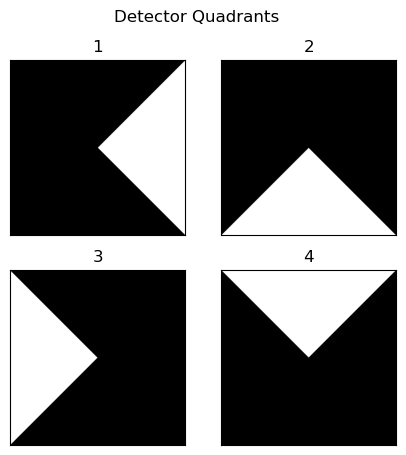

In [155]:
x, y = make_xy_grid(waffle_image.shape, diameter=1)

# set up diagonals
true_mask = np.zeros_like(A)
q1 = np.copy(true_mask)
q2 = np.copy(true_mask)
q3 = np.copy(true_mask)
q4 = np.copy(true_mask)

q1[(x > y) & (-x < y)] = 1
q2[(y > -x) & (x < y)] = 1
q3[(y > x) & (x < -y)] = 1
q4[(x > y) & (x < -y)] = 1

quarters = [q1, q2, q3, q4]
plt.figure(figsize=[5,5])
plt.suptitle("Detector Quadrants")
for i,q in enumerate(quarters):

    plt.subplot(2, 2, i+1)
    plt.title(f"{i+1}")
    plt.imshow(q, cmap="gray")
    plt.xticks([],[])
    plt.yticks([],[])

plt.show()

# Find the hotspot in each quadrant

In [156]:
val = np.argmax(q1 * waffle_image)

In [157]:
val

130876